In [69]:
# importing lib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [70]:
dt = load_breast_cancer()


In [71]:
# extracting the traget and features
x,y = dt.data, dt.target


In [72]:
## splitting the dataset
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)


In [73]:
ml = GradientBoostingClassifier( n_estimators=150,
    learning_rate=0.1,
    max_depth=5,
    max_features="sqrt",
    min_samples_leaf=3,
    random_state=42)

In [74]:
ml.fit(x_train, y_train)

GradientBoostingClassifier(max_depth=5, max_features='sqrt', min_samples_leaf=3,
                           n_estimators=150, random_state=42)

In [75]:
y_pre = ml.predict(x_test)
y_pretr = ml.predict(x_train)



In [76]:
# testing the accuracy
trainacc=print("Accuracy on training set:", accuracy_score(y_train, y_pretr))
test_acc=print("Accuracy on test set:", accuracy_score(y_test, y_pre))
print("\nClassification Report:\n", classification_report(y_test, y_pre, target_names=dt.target_names))

Accuracy on training set: 1.0
Accuracy on test set: 0.956140350877193

Classification Report:
               precision    recall  f1-score   support

   malignant       0.95      0.93      0.94        43
      benign       0.96      0.97      0.97        71

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



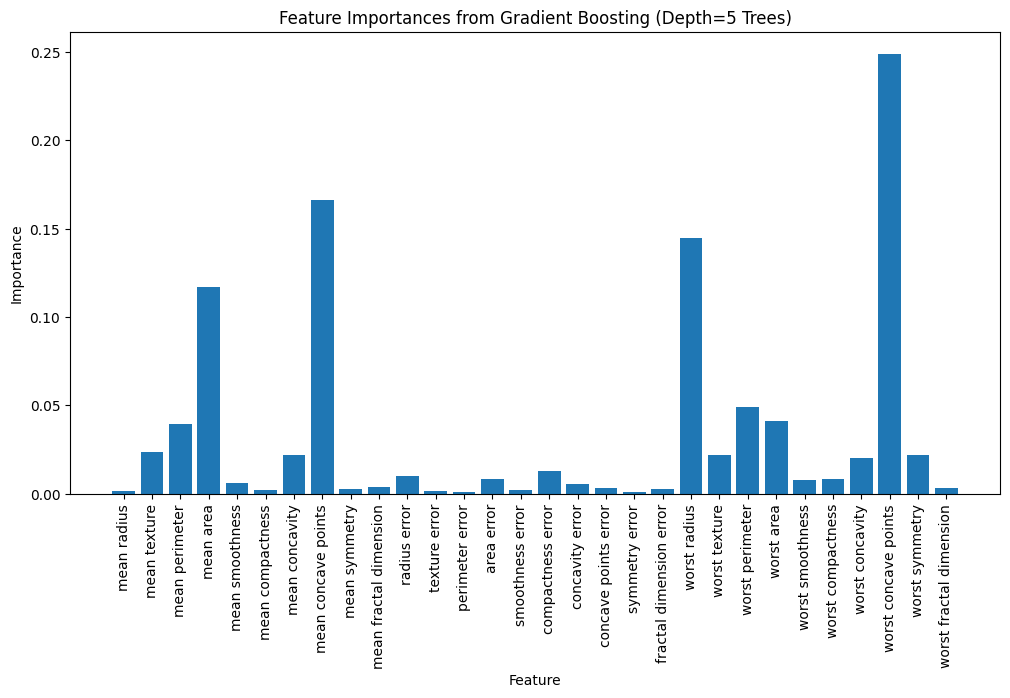

In [77]:

plt.figure(figsize=(12,6))
plt.bar(range(x.shape[1]), ml.feature_importances_)
plt.xticks(range(x.shape[1]), dt.feature_names, rotation=90)
plt.title("Feature Importances from Gradient Boosting (Depth=5 Trees)")
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.show()


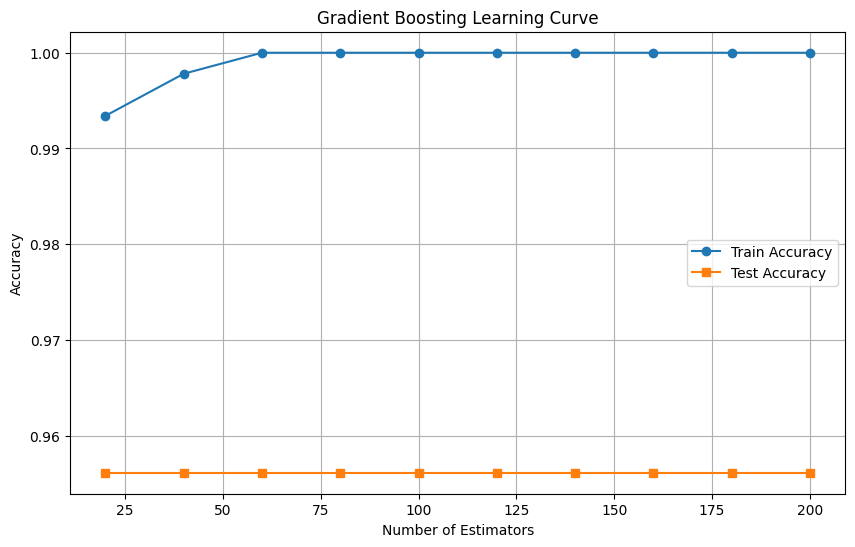

In [78]:
# learning curve
train_scores, test_scores = [], []
est_range = range(20, 201, 20)

for n in est_range:
    ml2 = GradientBoostingClassifier(
        n_estimators=n, learning_rate=0.1, max_depth=3, random_state=42
    )
    ml2.fit(x_train, y_train)
    train_scores.append(accuracy_score(y_train, ml2.predict(x_train)))
    test_scores.append(accuracy_score(y_test, ml2.predict(x_test)))

plt.figure(figsize=(10,6))
plt.plot(est_range, train_scores, label="Train Accuracy", marker="o")
plt.plot(est_range, test_scores, label="Test Accuracy", marker="s")
plt.title("Gradient Boosting Learning Curve")
plt.xlabel("Number of Estimators")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

In [79]:
print("\n--- Predictive System Example ---")
choice = input("Do you want to enter your own data? (yes/no): ")

if choice.lower() == "yes":
    user_data = []
    print("\nEnter the values for the following features:")
    for feature in dt.feature_names:
        val = float(input(f"{feature}: "))
        user_data.append(val)
    sample = np.array(user_data).reshape(1,-1)
else:
    # Default: pick a test sample
    idx = 15
    sample = x_test[idx].reshape(1, -1)
    print("\nUsing a test sample instead of manual input.")
    print("True Label:", dt.target_names[y_test[idx]])

# Prediction
prediction = ml.predict(sample)[0]
prediction_proba = ml.predict_proba(sample)[0]

print("\nPredicted Label:", dt.target_names[prediction])
print("Prediction Probabilities:", dict(zip(dt.target_names, prediction_proba)))


--- Predictive System Example ---
Do you want to enter your own data? (yes/no): no

Using a test sample instead of manual input.
True Label: malignant

Predicted Label: malignant
Prediction Probabilities: {np.str_('malignant'): np.float64(0.9999950354060595), np.str_('benign'): np.float64(4.964593940527435e-06)}
